In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt
import cv2
import random


Mounted at /content/drive


In [ ]:
dataset_path = '/content/drive/MyDrive/Dataset'  # Change to your actual path
img_size = 224


In [ ]:
def load_images_from_folder(folder, label):
    images = []
    for filename in os.listdir(folder):
        path = os.path.join(folder, filename)
        img = cv2.imread(path)
        if img is not None:
            img = cv2.resize(img, (img_size, img_size))
            images.append((img, label))
    return images

# Load images from both classes
class1 = load_images_from_folder(os.path.join(dataset_path, 'Class1'), 0)
class2 = load_images_from_folder(os.path.join(dataset_path, 'Class2'), 1)
all_data = class1 + class2


In [ ]:
def make_pairs(data):
    pairs = []
    labels = []

    # Positive pairs
    for i in range(len(data)-1):
        if data[i][1] == data[i+1][1]:
            pairs.append([data[i][0], data[i+1][0]])
            labels.append(1)

    # Negative pairs
    for i in range(len(data)//2):
        img1 = random.choice(class1)[0]
        img2 = random.choice(class2)[0]
        pairs.append([img1, img2])
        labels.append(0)

    return np.array(pairs), np.array(labels)

pairs, pair_labels = make_pairs(all_data)


In [ ]:
def build_embedding_model(input_shape=(img_size, img_size, 3)):
    input = layers.Input(shape=input_shape)
    x = layers.Conv2D(64, (3,3), activation='relu')(input)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, (3,3), activation='relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    return Model(input, x)

def euclidean_distance(vectors):
    x, y = vectors
    return tf.sqrt(tf.reduce_sum(tf.square(x - y), axis=1, keepdims=True))

input_shape = (img_size, img_size, 3)
embedding_model = build_embedding_model(input_shape)

input_a = layers.Input(shape=input_shape)
input_b = layers.Input(shape=input_shape)

features_a = embedding_model(input_a)
features_b = embedding_model(input_b)

distance = layers.Lambda(euclidean_distance)([features_a, features_b])
output = layers.Dense(1, activation='sigmoid')(distance)

siamese_model = Model(inputs=[input_a, input_b], outputs=output)


In [ ]:
siamese_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Prepare input data
pair_images_1 = np.array([pair[0] for pair in pairs])
pair_images_2 = np.array([pair[1] for pair in pairs])

# Normalize
pair_images_1 = pair_images_1 / 255.0
pair_images_2 = pair_images_2 / 255.0

# Train
siamese_model.fit(
    [pair_images_1, pair_images_2],
    pair_labels,
    validation_split=0.2,
    batch_size=16,
    epochs=20
)


Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 50s 9s/step - accuracy: 0.1883 - loss: nan - val_accuracy: 1.0000 - val_loss: nan
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 78s 9s/step - accuracy: 0.1629 - loss: nan - val_accuracy: 1.0000 - val_loss: nan
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 44s 9s/step - accuracy: 0.1594 - loss: nan - val_accuracy: 1.0000 - val_loss: nan
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 46s 10s/step - accuracy: 0.1924 - loss: nan - val_accuracy: 1.0000 - val_loss: nan
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 82s 10s/step - accuracy: 0.1629 - loss: nan - val_accuracy: 1.0000 - val_loss: nan
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 83s 10s/step - accuracy: 0.1777 - loss: nan - val_accuracy: 1.0000 - val_loss: nan
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 82s 9s/step - accuracy: 0.2063 - loss: nan - val_accuracy: 1.0000 - val_loss: nan
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 81s 9s/step - accuracy: 0.1464 - loss: nan - val_accuracy: 1.0000 - val_loss: nan
Epoch 9/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 82s 9s/step - acc

In [ ]:
siamese_model.save('/content/drive/MyDrive/siamese_network.h5')


In [ ]:
!ls "/content/drive/MyDrive/facemodel"


siamese_network.h5


Mounted at /content/drive


📤 Please upload the FIRST image


Saving img1.jpg to img1.jpg
📤 Please upload the SECOND image


Saving img3.jpg to img3.jpg


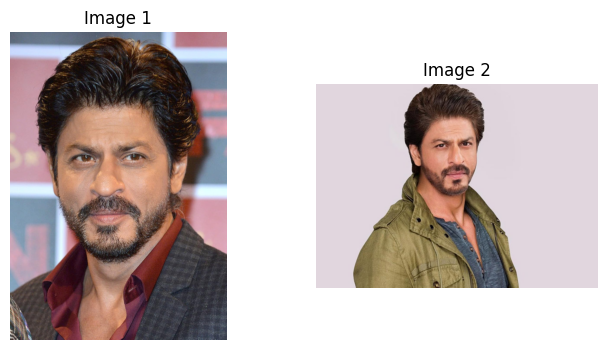

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 723ms/step

Similarity Score: nan
❌ Different person


In [2]:
# Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Step 2: Import Required Libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from IPython.display import display
from PIL import Image

# Step 3: Define the Custom Function Used in Model
import tensorflow.keras.backend as K

def euclidean_distance(vectors):
    x, y = vectors
    sum_square = K.sum(K.square(x - y), axis=1, keepdims=True)
    return K.sqrt(K.maximum(sum_square, K.epsilon()))

# Step 4: Load Trained Model (with Custom Object)
model_path = "/content/drive/MyDrive/facemodel/siamese_network.h5"
model = load_model(model_path, custom_objects={'euclidean_distance': euclidean_distance})

# Step 5: Set Image Size (same as training)
img_size = 224

# Step 6: Define Prediction Function
def predict_similarity(img1_path, img2_path, model, threshold=0.5):
    img1 = cv2.imread(img1_path)
    img2 = cv2.imread(img2_path)

    img1 = cv2.resize(img1, (img_size, img_size)) / 255.0
    img2 = cv2.resize(img2, (img_size, img_size)) / 255.0

    img1 = np.expand_dims(img1, axis=0)
    img2 = np.expand_dims(img2, axis=0)

    pred = model.predict([img1, img2])[0][0]
    print(f"\nSimilarity Score: {pred:.4f}")
    if pred < threshold:
        print("✅ Same person")
    else:
        print("❌ Different person")

# Step 7: Upload Images for Testing
from google.colab import files
print("📤 Please upload the FIRST image")
uploaded1 = files.upload()
img1_path = list(uploaded1.keys())[0]

print("📤 Please upload the SECOND image")
uploaded2 = files.upload()
img2_path = list(uploaded2.keys())[0]

# Step 8: Show Images Side-by-Side
img1_display = Image.open(img1_path)
img2_display = Image.open(img2_path)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(img1_display)
ax[0].axis("off")
ax[0].set_title("Image 1")
ax[1].imshow(img2_display)
ax[1].axis("off")
ax[1].set_title("Image 2")
plt.show()

# Step 9: Predict
predict_similarity(img1_path, img2_path, model)
